In [2]:
import sys
from pathlib import Path

# notebook lives in backend/app/chat/
chat_dir = Path.cwd()
backend_dir = chat_dir.parent.parent
repo_root = backend_dir.parent

sys.path.append(str(backend_dir))
sys.path.append(str(repo_root))

In [3]:
from app.chat.langgraph_agent import build_retrival_graph
from app.chat.langgraph_agent import create_model
from app.chat.schemas import PromptInput
from pydantic import BaseModel
from typing import List
# from app.chat.tools import retrieve_user_documents,tavily,behavioral_scoring,calculate_financial_wellbeing,get_macro_context,calculate_amortization
from app.chat.tools import (
    retrieve_user_documents,
    tavily,
    behavioral_scoring,
    calculate_financial_wellbeing,
    get_macro_context,
    calculate_amortization,
)

c:\Users\Personal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
create_model

<function app.chat.langgraph_agent.create_model(model_name: str, streaming: bool = False) -> langchain_core.language_models.chat_models.BaseChatModel>

In [ ]:
from typing import TypedDict, Annotated, Any, List
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    user_id: str
    thread_id: str
    query: str
    tool_plan: list[str]
    tool_results: dict
    draft_response: dict
    validated_response: dict
    final_response: str
    validation_log: list
    iteration_count: int
    error: str


In [21]:
from typing import List, TypedDict, Annotated
from pydantic import BaseModel
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
# class AgentState(TypedDict):
#     messages: Annotated[list[BaseMessage], add_messages]
#     user_id: str
#     thread_id: str
#     query: str
#     tool_plan: list[str]
#     tool_results: dict
#     draft_response: dict
#     validated_response: dict
#     final_response: str
#     validation_log: list
#     iteration_count: int
#     error: str


class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    user_id: str
    thread_id: str
    query: str
    tool_plan: list
    extracted_context: dict
    missing_inputs: dict
    tool_results: dict
    draft_response: dict
    validated_response: dict
    final_response: str
    validation_log: list
    iteration_count: int
    error: str

TOOL_REQUIREMENTS = {
    "financial": [
        "income",
        "expenses",
    ],
    "behavioral": [],
    "macro": [],
    "amortization": [
        "principal",
        "annual_interest_rate",
        "term_months",
    ]
}

class ToolCall(BaseModel):
    name: str
    arguments: dict[str, Any] = {}


class ToolPlan(BaseModel):
    tool_calls: list[ToolCall]
    reasoning: str

llm = create_model("openrouter/free")
planner_llm = llm.with_structured_output(ToolPlan)

def planner_node(state: AgentState):
    query = state["query"]

    planner_prompt = f"""
You are the Planner for a financial advisory AI.

USER QUERY: {query}

AVAILABLE TOOLS:
1. Financial Wellbeing - Returns income, expenses, savings, DTI, credit score
2. Behavioral Preferences - Returns persona and traits (risk/debt aversion, etc.)
3. Amortization Calculator - Returns loan payment schedule (requires principal, rate, term)
4. Macro Economic Indicators - Returns inflation, interest rates, GDP trends
5. User's Persona - Returns persona profile (already covered in tool 2)

DECISION RULES:
- If query involves loan, mortgage, or repayment → Call tools 1, 2, 3, 4
- If query involves financial planning → Call tools 1, 2, 4
- If query is general knowledge → Call no tools
- If query mentions "what if" or scenario → Call all 5 tools

Return a JSON list of tool names to call.
"""

    result = planner_llm.invoke(planner_prompt)

    return {
        "tool_plan": result.tools,
    }

In [ ]:

from pydantic import BaseModel
from typing import Optional

class ExtractedContext(BaseModel):
    income: Optional[float] = None
    expenses: Optional[float] = None
    principal: Optional[float] = None
    annual_interest_rate: Optional[float] = None
    term_months: Optional[int] = None

extractor_llm = llm.with_structured_output(
    ExtractedContext
)

def context_extractor_node(state: AgentState):
    query = state["query"]
    extracted = extractor_llm.invoke(
        f"""
        Extract financial information.

        Query:
        {query}

        Return structured data.
        """
    )
    return {
        "extracted_context": extracted.model_dump()
    }

In [15]:
def input_validation_node(state: AgentState):

    context = state["extracted_context"]

    missing_inputs = {}

    for tool_call in state["tool_plan"]:

        tool_name = tool_call.name

        required = TOOL_REQUIREMENTS.get(
            tool_name,
            []
        )

        missing = []

        for field in required:

            if context.get(field) is None:
                missing.append(field)

        if missing:
            missing_inputs[tool_name] = missing

    return {
        "missing_inputs": missing_inputs
    }

In [16]:
def ask_for_missing_inputs_node(
    state: AgentState
):

    missing = state["missing_inputs"]

    if not missing:
        return {}

    questions = []

    for tool, fields in missing.items():

        questions.append(
            f"For {tool}, I need: "
            + ", ".join(fields)
        )

    return {
        "final_response": "\n".join(
            questions
        )
    }

In [19]:
def build_tool_arguments(
    tool_name: str,
    state: AgentState
):

    context = state["extracted_context"]

    if tool_name == "financial":

        return {
            "income": context["income"],
            "expenses": context["expenses"]
        }

    elif tool_name == "behavioral":

        return {
            "user_id": state["user_id"]
        }

    elif tool_name == "macro":

        return {
            "country": "gr"
        }

    elif tool_name == "amortization":

        return {
            "principal":
                context["principal"],

            "annual_interest_rate":
                context["annual_interest_rate"],

            "term_months":
                context["term_months"]
        }

    return {}

In [17]:
from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed
)


def executor_node(state: AgentState):

    results = {}

    with ThreadPoolExecutor() as pool:

        futures = {}

        for tool_call in state["tool_plan"]:

            args = build_tool_arguments(
                tool_call.name,
                state
            )

            futures[
                pool.submit(
                    TOOL_MAP[
                        tool_call.name
                    ].invoke,
                    args
                )
            ] = tool_call.name

        for future in as_completed(
            futures
        ):

            tool_name = futures[future]

            results[tool_name] = (
                future.result()
            )

    return {
        "tool_results": results
    }

In [7]:
from langchain_core.messages import HumanMessage

test_state: AgentState = {
    "messages": [HumanMessage(content="Can I afford a car loan?")],
    "user_id": "user-123",
    "thread_id": "thread-123",
    "query": "Can I afford a car loan?",
    "tool_plan": [],
    "tool_results": {},
    "draft_response": {},
    "validated_response": {},
    "final_response": "",
    "validation_log": [],
    "iteration_count": 0,
    "error": "",
}

output = planner_node(test_state)
print(output)

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


{'tool_plan': ['Financial Wellbeing', 'Behavioral Preferences', 'Amortization Calculator', 'Macro Economic Indicators']}


## New Multi-Agent Flow

In [4]:
from typing import TypedDict, Annotated, Any, List
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from pydantic import BaseModel

In [5]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    user_id: str
    thread_id: str
    query: str

class ToolPlan(BaseModel):
    tool_calls: List[str]
    reasoning: str

llm = create_model("openrouter/free")
planner_llm = llm.with_structured_output(ToolPlan)

def planner_node(state: AgentState):
    query = state["query"]

    planner_prompt = f"""
You are the Planner for a financial advisory AI.

USER QUERY: {query}

AVAILABLE TOOLS:
1. Financial Wellbeing - Returns income, expenses, savings, DTI, credit score
2. Behavioral Preferences - Returns persona and traits (risk/debt aversion, etc.)
3. Amortization Calculator - Returns loan payment schedule (requires principal, rate, term)
4. Macro Economic Indicators - Returns inflation, interest rates, GDP trends
5. User's Persona - Returns persona profile (already covered in tool 2)

DECISION RULES:
- If query involves loan, mortgage, or repayment → Call tools 1, 2, 3, 4
- If query involves financial planning → Call tools 1, 2, 4
- If query is general knowledge → Call no tools
- If query mentions "what if" or scenario → Call all 5 tools

Return a JSON list of tool names to call.
"""

    result = planner_llm.invoke(planner_prompt)
    print(result.tool_calls)
    return {
        "tool_plan": result,
    }

In [6]:
from langchain_core.messages import HumanMessage

test_state: AgentState = {
    "messages": [HumanMessage(content="Can I afford a car loan? if i have 4k usd in bank.")],
    "user_id": "user-123",
    "thread_id": "thread-123",
    "query": "Can I afford a car loan? if i have 4k usd in bank.",
}

output = planner_node(test_state)
print(output)

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


['Financial Wellbeing', 'Behavioral Preferences', 'Amortization Calculator', 'Macro Economic Indicators', "User's Persona"]
{'tool_plan': ToolPlan(tool_calls=['Financial Wellbeing', 'Behavioral Preferences', 'Amortization Calculator', 'Macro Economic Indicators', "User's Persona"], reasoning='The query is a what‑if scenario about taking a car loan, which triggers the rule to call all five available tools.')}


In [7]:
"""
Feature-extraction prompt builder for the agentic RAG node.

Given a user query + a list of tool display names, this builds a system
prompt that asks the LLM to extract exactly the parameters each selected
tool needs, and return them as a single JSON object keyed by short tool
name (matching your `tools_features` shape).
"""

from typing import Dict, List

# Maps the human-facing tool name -> the short key used in tools_features,
# and the field schema the LLM should extract for that tool.
TOOL_REGISTRY: Dict[str, Dict] = {
    "Financial Wellbeing": {
        "key": "financial",
        "fn": "calculate_financial_wellbeing",
        "fields": {
            "monthly_income": "Take-home pay per month, in currency units (e.g. 4000).",
            "monthly_expenses": "Total regular monthly spending excluding debt payments — rent, bills, food, etc. (e.g. 2500).",
            "monthly_debt_payments": "Total monthly payments toward all debts/loans/credit cards (e.g. 500).",
            "savings_balance": "Current total liquid savings (e.g. 3000).",
            "late_payments_last_6_months": "Count of missed/late payments or overdrafts in the last 6 months (e.g. 0, 1, 2). Default to 0 if not mentioned.",
            "high_interest_debt_amount": "Amount owed specifically on high-interest debt, e.g. credit cards (e.g. 5000). Default to 0 if not mentioned.",
            "total_debt_amount": "Total amount owed across all debts (e.g. 10000). Default to 0 if not mentioned.",
        },
    },
    "Behavioral Preferences": {
        "key": "behavioral",
        "fn": "behavioral_scoring",
        "fields": {
            "debtrules3": "Score 1-5: response to the 'debt rules' survey item 3.",
            "debtnorms8": "Score 1-5: response to the 'debt norms' survey item 8.",
            "debtrules16": "Score 1-5: response to the 'debt rules' survey item 16.",
            "debtpers5": "Score 1-5: response to the 'debt personality' survey item 5.",
            "debtnorms9": "Score 1-5: response to the 'debt norms' survey item 9.",
            "debtpers9": "Score 1-5: response to the 'debt personality' survey item 9.",
            "debtpers11": "Score 1-5: response to the 'debt personality' survey item 11.",
            "debtrules9": "Score 1-5: response to the 'debt rules' survey item 9.",
        },
    },
    "Amortization Calculator": {
        "key": "amortization",
        "fn": "calculate_amortization",
        "fields": {
            "principal": "Loan amount, in currency units (e.g. 20000).",
            "annual_interest_rate": "Annual interest rate as a percent number (e.g. 6.5, not 0.065).",
            "term_months": "Loan term in months (e.g. 5 years -> 60).",
        },
    },
    "Macro Economic Indicators": {
        "key": "macro",
        "fn": "get_macro_context",
        "fields": {
            "country_code": "2- or 3-letter ISO country code (e.g. 'us', 'gr').",
        },
    },
}


def build_feature_extraction_prompt(query: str, tool_names: List[str]) -> str:
    """
    Build the system+user prompt for the feature-extraction node.

    Args:
        query: The raw user query / conversation snippet to extract from.
        tool_names: Subset of TOOL_REGISTRY keys the router decided are relevant,
            e.g. ['Financial Wellbeing', 'Amortization Calculator'].

    Returns:
        A single prompt string ready to send to the LLM.
    """
    selected = {name: TOOL_REGISTRY[name] for name in tool_names if name in TOOL_REGISTRY}

    schema_lines = []
    example_keys = []
    for name, spec in selected.items():
        example_keys.append(spec["key"])
        schema_lines.append(f'\n### {name}  ->  key: "{spec["key"]}"')
        for field, desc in spec["fields"].items():
            schema_lines.append(f'- {field}: {desc}')

    schema_text = "\n".join(schema_lines)

    example_json = "{\n" + ",\n".join(
        f'  "{k}": {{ ... }}' for k in example_keys
    ) + "\n}"

    prompt = f"""You are a feature-extraction node in an agentic RAG financial assistant.

Your ONLY job: read the user query below and pull out the specific input
values needed to call each of the following tools. Do not answer the
query, do not call any tool yourself, and do not explain your reasoning.

TOOLS AND REQUIRED FIELDS:
{schema_text}

EXTRACTION RULES:
1. Only include the tool keys listed above ({', '.join(example_keys)}) — nothing else.
2. For each tool, extract only the fields listed for it.
3. If a field's value is not stated or clearly inferable from the query,
   set it to null. Never guess or fabricate a number.
4. Convert percentages to decimals only where the field description says
   to (e.g. dti, savings_rate) — leave fields that say "as a percent
   number" (e.g. annual_interest_rate) as plain numbers.
5. If the query does not contain enough information for a tool at all,
   still include that tool's key with all its fields set to null.
6. Output ONLY valid JSON — no markdown fences, no commentary, no
   trailing text.

OUTPUT FORMAT (keys must match exactly):
{example_json}

USER QUERY:
\"\"\"{query}\"\"\"

Return the JSON now.
"""
    return prompt


# if __name__ == "__main__":
#     # quick smoke test
#     demo_query = (
#         "I make about 4000 a month, my DTI is roughly 35%, I've got about "
#         "2 months of expenses saved, and I want to know what a 15000 loan "
#         "at 7.2% over 4 years would cost me. I'm based in Greece."
#     )
#     demo_tools = [
#         "Financial Wellbeing",
#         "Amortization Calculator",
#         "Macro Economic Indicators",
#     ]
#     print(build_feature_extraction_prompt(demo_query, demo_tools))

In [8]:
# from feature_extraction_prompt import build_feature_extraction_prompt
import json

users_behavioral_quessionare = {
  'debtrules3': 2,
  'debtnorms8': 1,
  'debtrules16': 5,
  'debtpers5': 3,
  'debtnorms9': 1,
  'debtpers9': 2,
  'debtpers11': 3,
  'debtrules9': 1
}

user_query = f"""User's Behavioral Values: {users_behavioral_quessionare}, I make about 4000 a month, my DTI is roughly 35%, I've got about 2 months of expenses saved, and I want to know what a 15000 loan at 7.2% over 4 years would cost me. I'm based in Greece."""


prompt = build_feature_extraction_prompt(
    query=user_query,
    tool_names=["Financial Wellbeing", "Behavioral Preferences",
                "Amortization Calculator", "Macro Economic Indicators"],
)

response = await llm.ainvoke(prompt)
tools_features = json.loads(response.content)  # wrap in try/except for malformed JSON

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


In [9]:
tools_features

{'financial': {'monthly_income': 4000,
  'monthly_expenses': None,
  'monthly_debt_payments': 1400,
  'savings_balance': None,
  'late_payments_last_6_months': None,
  'high_interest_debt_amount': None,
  'total_debt_amount': None},
 'behavioral': {'debtrules3': 2,
  'debtnorms8': 1,
  'debtrules16': 5,
  'debtpers5': 3,
  'debtnorms9': 1,
  'debtpers9': 2,
  'debtpers11': 3,
  'debtrules9': 1},
 'amortization': {'principal': 15000,
  'annual_interest_rate': 7.2,
  'term_months': 48},
 'macro': {'country_code': 'gr'}}

### AGENT

In [10]:
import json
from typing import Annotated, Dict, List, TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel

from app.chat.langgraph_agent import create_model
# from feature_extraction_prompt import TOOL_REGISTRY, build_feature_extraction_prompt
from tools import (
    behavioral_scoring,
    calculate_amortization,
    calculate_financial_wellbeing,
    get_macro_context,
)


class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    user_id: str
    thread_id: str
    query: str
    tool_plan: List[str]          # e.g. ["Financial Wellbeing", "Amortization Calculator"]
    tools_features: Dict          # e.g. {"financial": {...}, "amortization": {...}}
    tool_results: Dict            # e.g. {"financial": {...result}, "amortization": {...result}}
    aggregated_context: str       # tool_results flattened into one block for the response node


class ToolPlan(BaseModel):
    tool_calls: List[str]
    reasoning: str


llm = create_model("openrouter/free")
planner_llm = llm.with_structured_output(ToolPlan)


def planner_node(state: AgentState):
    query = state["query"]

    planner_prompt = f"""
You are the Planner for a financial advisory AI.

USER QUERY: {query}

AVAILABLE TOOLS:
1. Financial Wellbeing - Returns income, expenses, savings, DTI, credit score
2. Behavioral Preferences - Returns persona and traits (risk/debt aversion, etc.)
3. Amortization Calculator - Returns loan payment schedule (requires principal, rate, term)
4. Macro Economic Indicators - Returns inflation, interest rates, GDP trends

DECISION RULES:
- If query involves loan, mortgage, or repayment -> Call tools 1, 2, 3, 4
- If query involves financial planning -> Call tools 1, 2, 4
- If query is general knowledge -> Call no tools
- If query mentions "what if" or scenario -> Call all 4 tools

Return the exact tool names above (not numbers) in tool_calls.
"""

    try:
        result = planner_llm.invoke(planner_prompt)
        tool_plan = result.tool_calls
    except Exception as e:
        # Model didn't return valid structured output (common with free-tier
        # models that don't support tool calling reliably). Fail soft.
        print(f"planner_node: structured output failed ({e}), defaulting to no tools")
        tool_plan = []

    print(tool_plan)
    return {"tool_plan": tool_plan}


def route_after_planner(state: AgentState):
    # No tools needed (general knowledge query) -> skip straight past tool
    # execution so we don't call an empty aggregate step on nothing.
    return "feature_extraction" if state.get("tool_plan") else "aggregate_results"


def feature_extraction_node(state: AgentState):
    tool_plan = state.get("tool_plan") or []
    prompt = build_feature_extraction_prompt(query=state["query"], tool_names=tool_plan)

    response = llm.invoke(prompt)

    try:
        tools_features = json.loads(response.content)
    except json.JSONDecodeError:
        # Model didn't return clean JSON - fail soft with nothing extracted
        # rather than crashing the graph.
        tools_features = {}

    return {"tools_features": tools_features}


# Maps the short key (used in tools_features) -> the actual callable tool.
TOOL_KEY_TO_FUNC = {
    "financial": calculate_financial_wellbeing,
    "behavioral": behavioral_scoring,
    "amortization": calculate_amortization,
    "macro": get_macro_context,
}


def tool_execution_node(state: AgentState):
    tools_features = state.get("tools_features") or {}
    tool_results = {}

    for key, func in TOOL_KEY_TO_FUNC.items():
        if key not in tools_features:
            continue

        args = tools_features[key]

        try:
            tool_results[key] = func.invoke(args)
        except Exception as e:
            # Most common cause: the LLM couldn't find a required field in
            # conversation, so it came back as null and the calculation
            # can't run. Surface it instead of crashing the whole graph.
            tool_results[key] = {"error": str(e)}

    return {"tool_results": tool_results}


def aggregate_results_node(state: AgentState):
    tool_results = state.get("tool_results") or {}

    # Simple pass-through for now: just serialize everything into one text
    # block the response-generation node can drop straight into its prompt.
    # Swap this for smarter merging/summarizing later if needed.
    aggregated_context = json.dumps(tool_results, indent=2) if tool_results else ""

    return {"aggregated_context": aggregated_context}


graph = StateGraph(AgentState)
graph.add_node("planner", planner_node)
graph.add_node("feature_extraction", feature_extraction_node)
graph.add_node("tool_execution", tool_execution_node)
graph.add_node("aggregate_results", aggregate_results_node)

graph.set_entry_point("planner")
graph.add_conditional_edges(
    "planner",
    route_after_planner,
    {"feature_extraction": "feature_extraction", "aggregate_results": "aggregate_results"},
)
graph.add_edge("feature_extraction", "tool_execution")
graph.add_edge("tool_execution", "aggregate_results")
graph.add_edge("aggregate_results", END)  # TODO: replace with response_generation node

app = graph.compile()

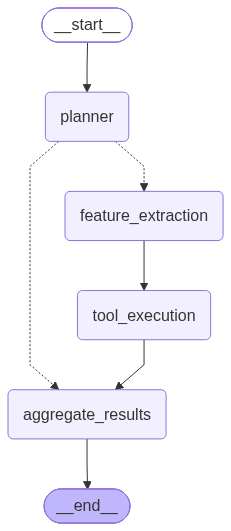

In [11]:
app

In [12]:
result = app.invoke({
    "query": "I want to know what a 15000 loan at 7.2% over 4 years would cost me, I make 4000/month",
    "messages": [],
    "user_id": "test-user",
    "thread_id": "test-thread",
})

print(result["tool_plan"])
print(result["tools_features"])
print(result["tool_results"])
print(result["aggregated_context"])

INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


planner_node: structured output failed ('NoneType' object has no attribute 'tool_calls'), defaulting to no tools
[]
[]


KeyError: 'tools_features'

In [13]:
result

{'messages': [],
 'user_id': 'test-user',
 'thread_id': 'test-thread',
 'query': 'I want to know what a 15000 loan at 7.2% over 4 years would cost me, I make 4000/month',
 'tool_plan': [],
 'aggregated_context': ''}